In [81]:
import pandas as pd
import networkx as nx
import json
from collections import defaultdict
import community.community_louvain as community_louvain
from matplotlib import pyplot as plt
import numpy as np
import random
import itertools



In [27]:
def represent_degree_distribution(G,node_list,scale='linear',rep='bars', title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees=list(degree_counts.keys())
    degree_count=list(degree_counts.values())

    fig,ax=plt.subplots(1,1,figsize=(5,5))
    if rep=='bars':
        ax.bar(degrees,degree_count)
    if rep=='scatter':
        ax.scatter(degrees,degree_count)
    
    if scale=='log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_xlabel('Degree',fontsize=15)
    ax.set_ylabel('#nodes',fontsize=15)
    ax.tick_params(which='major',axis='both',labelsize=15) 
    ax.set_title(title)

In [26]:
def fit_CCDF(G,node_list, title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    degrees=[degrees[i] for i in range(len(degrees)) if degree_count[i]!=0]
    degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

    
    cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
    ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

    log_degree_fit=[np.log(degrees[i]) for i in range(len(degrees))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
    log_ccdf_fit=np.log(ccdf)[:-1]

    m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

    theoretical=[np.exp(b)*k**m for k in degrees]

    fig,ax=plt.subplots(1,1,figsize=(5,5))

    ax.plot(degrees, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
    ax.scatter(degrees, ccdf,label='data')


    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel('$k$',fontsize=15)
    ax.set_ylabel('$CCDF(k)$',fontsize=15)

    ax.tick_params(which='major',axis='both',labelsize=15)

    ax.legend()
    ax.set_title(title)

In [18]:
# =========================================================
# LOAD JSON
# =========================================================

with open(
    "./doi_10_5061_dryad_dr7sqv9v8__v20200626/"
    "NJC19_network_data_and_code/"
    "NJC19_network.json"
) as f:

    data = json.load(f)

# =========================================================
# CREATE DIRECTED BIPARTITE MULTIGRAPH
# =========================================================
#
# WHY MultiDiGraph?
#
# - Multi:
#   same species/metabolite pair can have
#   multiple interaction types
#
# - Di:
#   direction represents metabolic flow
#
# - Bipartite:
#   species and metabolites are separate node sets
#
# =========================================================

B = nx.MultiDiGraph()

# =========================================================
# ACTIVITY CLASSIFICATION
# =========================================================

activity_map = {

    "Consumption (import)": {
        "category": "import",
        "sign": 1
    },

    "Production (export)": {
        "category": "export",
        "sign": 1
    },

    "Consumption (import), Production (export)": {
        "category": "exchange",
        "sign": 1
    },

    "Macromolecule degradation": {
        "category": "degradation",
        "sign": 1
    },

    "Consumption (import) (-)": {
        "category": "import",
        "sign": -1
    },

    "Production (export) (-)": {
        "category": "export",
        "sign": -1
    },

    "Macromolecule degradation (-)": {
        "category": "degradation",
        "sign": -1
    }
}

# =========================================================
# BUILD NETWORK
# =========================================================

for interaction_id, interaction in data.items():

    # -----------------------------------------------------
    # Extract fields
    # -----------------------------------------------------

    species = interaction["Species"].strip().lower()

    metabolite = interaction[
        "Small-molecule metabolite or macromolecule"
    ].strip().lower()

    activity = interaction["Metabolic activity"]

    refs = interaction["Ref. #"]

    # -----------------------------------------------------
    # Parse activity metadata
    # -----------------------------------------------------

    parsed = activity_map[activity]

    category = parsed["category"]
    sign = parsed["sign"]

    # -----------------------------------------------------
    # Add species node
    # -----------------------------------------------------

    B.add_node(
        species,

        bipartite=0,
        node_type="species",

        label=species
    )

    # -----------------------------------------------------
    # Add metabolite node
    # -----------------------------------------------------

    B.add_node(
        metabolite,

        bipartite=1,
        node_type="metabolite",

        label=metabolite
    )

    # =====================================================
    # DEFINE EDGE DIRECTION
    # =====================================================
    #
    # IMPORT:
    # metabolite -> species
    #
    # EXPORT:
    # species -> metabolite
    #
    # EXCHANGE:
    # both directions
    #
    # DEGRADATION:
    # metabolite -> species
    #
    # =====================================================

    # -----------------------------------------------------
    # IMPORT
    # -----------------------------------------------------

    if category == "import":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXPORT
    # -----------------------------------------------------

    elif category == "export":

        B.add_edge(
            species,
            metabolite,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXCHANGE
    # -----------------------------------------------------

    elif category == "exchange":

        # species exports metabolite
        B.add_edge(
            species,
            metabolite,

            interaction_id=f"{interaction_id}_export",

            activity=activity,
            category="export",

            sign=sign,

            refs=refs
        )

        # species imports metabolite
        B.add_edge(
            metabolite,
            species,

            interaction_id=f"{interaction_id}_import",

            activity=activity,
            category="import",

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # DEGRADATION
    # -----------------------------------------------------

    elif category == "degradation":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

# =========================================================
# BASIC SUMMARY
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 0
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 1
]

print("=" * 60)
print("DIRECTED BIPARTITE METABOLIC NETWORK")
print("=" * 60)

print(f"Total nodes: {B.number_of_nodes()}")
print(f"Total edges: {B.number_of_edges()}")

print()

print(f"Species nodes: {len(species_nodes)}")
print(f"Metabolite nodes: {len(metabolite_nodes)}")

# =========================================================
# CHECK BIPARTITE STRUCTURE
# =========================================================

is_bipartite = nx.is_bipartite(B)

print()
print(f"Is bipartite: {is_bipartite}")


# =========================================================
# EDGE CATEGORY COUNTS
# =========================================================

from collections import Counter

edge_categories = Counter()

for _, _, data in B.edges(data=True):

    edge_categories[data["category"]] += 1

print()
print("Edge categories:")

for category, count in edge_categories.items():

    print(f"  {category}: {count}")

# =========================================================
# OPTIONAL:
# SHOW EXAMPLE EDGES
# =========================================================

print()
print("=" * 60)
print("EXAMPLE EDGES")
print("=" * 60)

for i, (u, v, d) in enumerate(B.edges(data=True)):

    print(
        f"{u} -> {v} | "
        f"{d['category']} | "
        f"sign={d['sign']}"
    )

    if i >= 9:
        break

DIRECTED BIPARTITE METABOLIC NETWORK
Total nodes: 1127
Total edges: 9316

Species nodes: 844
Metabolite nodes: 283

Is bipartite: True

Edge categories:
  export: 3041
  import: 5798
  degradation: 477

EXAMPLE EDGES
absiella dolichum -> acetate | export | sign=1
absiella dolichum -> butyrate | export | sign=1
absiella dolichum -> h2s (hs-) | export | sign=-1
absiella dolichum -> l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate) | export | sign=1
absiella dolichum -> nh3 (ammonia, nh4+, ammonium) | export | sign=1
absiella dolichum -> pyruvate | export | sign=1
absiella dolichum -> succinate | export | sign=1
acetate -> actinosynnema mirum | import | sign=-1
acetate -> alicycliphilus denitrificans | import | sign=1
acetate -> anaerobutyricum hallii | import | sign=1


## Analyzing the bipartite network

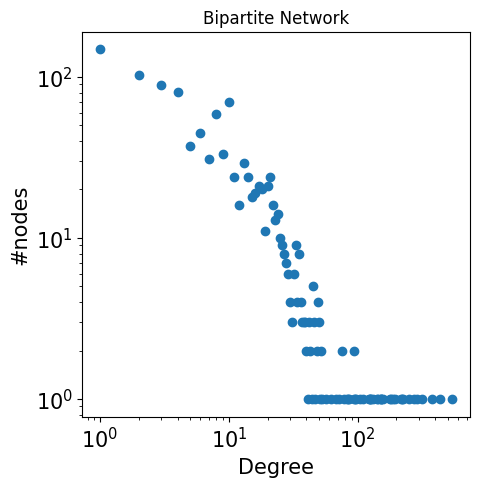

In [28]:
represent_degree_distribution(B,node_list=B.nodes(),scale='log',rep='scatter', title='Bipartite Network') ## Represent the degree distribution of the graph with a scatter plot and log scale


/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_86736/1294712512.py:20: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


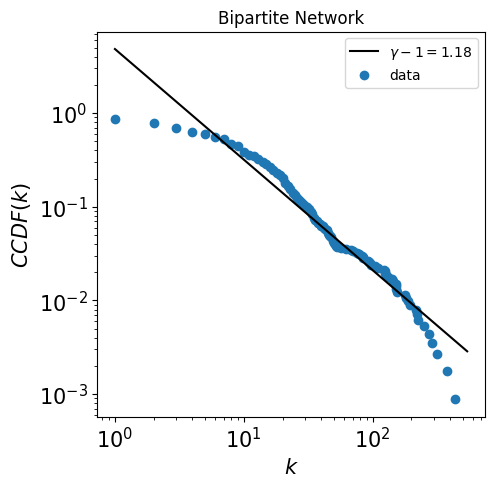

In [29]:
fit_CCDF(B,node_list=B.nodes(), title='Bipartite Network') ## Fit the CCDF of the degree distribution with a power law and represent it in a log-log scale

Species table

Here we identify

generalist bacteria (high degree)
specialists (low degree)

Metabolite table

hub metabolites (used by many species)
rare metabolites (specialized compounds)

In [ ]:
# =========================================================
# ASSUMPTION:
# B is already built and contains:
# - species nodes (bipartite=0)
# - metabolite nodes (bipartite=1)
# - directed edges species ↔ metabolites
# =========================================================

# =========================================================
# SPLIT NODES BY TYPE
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

# =========================================================
# DEGREE CALCULATION FUNCTIONS
# =========================================================
#
# In a directed bipartite metabolic network:
# - degree = total interactions (in + out)
# - in-degree = what comes into node
# - out-degree = what leaves node
#
# =========================================================

def compute_degrees(G, nodes):

    results = []

    for n in nodes:

        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)
        total = indeg + outdeg

        results.append({
            "node": n,
            "in_degree": indeg,
            "out_degree": outdeg,
            "total_degree": total
        })

    return pd.DataFrame(results)

# =========================================================
# SPECIES DEGREE ANALYSIS
# =========================================================

species_df = compute_degrees(B, species_nodes)
species_df = species_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP SPECIES BY DEGREE")
print("="*60)
print(species_df.head(20))

# =========================================================
# METABOLITE DEGREE ANALYSIS
# =========================================================

metabolite_df = compute_degrees(B, metabolite_nodes)
metabolite_df = metabolite_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP METABOLITES BY DEGREE")
print("="*60)
print(metabolite_df.head(20))

# =========================================================
# SUMMARY STATS
# =========================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nSpecies degree stats:")
print(species_df["total_degree"].describe())

print("\nMetabolite degree stats:")
print(metabolite_df["total_degree"].describe())


TOP SPECIES BY DEGREE
                             node  in_degree  out_degree  total_degree
838              human colonocyte        120           4           124
843         mouse intestinal cell         60          18            78
106  bacteroides thetaiotaomicron         47          29            76
120        bifidobacterium longum         40          22            62
116         bifidobacterium breve         38          14            52
311              escherichia coli         21          28            49
216       clostridium perfringens         30          18            48
292         enterococcus faecalis         32          15            47
115       bifidobacterium bifidum         30          16            46
97             bacteroides ovatus         31          15            46
112  bifidobacterium adolescentis         31          15            46
446       lactobacillus plantarum         31          14            45
108          bacteroides vulgatus         34          

## Analyzing Bipartite Network individually

In [142]:
# =========================================================
# CENTRALITY MEASURES (Directly from original MultiGraph B)
# =========================================================

degree_centrality = nx.degree_centrality(B)
betweenness_centrality = nx.betweenness_centrality(B)
closeness_centrality = nx.closeness_centrality(B)

# NetworkX requires a simple graph for Eigenvector Centrality
# We cast it inline here so B itself remains completely untouched
B_simple_temp = nx.DiGraph(B) if B.is_directed() else nx.Graph(B)
eigenvector_centrality = nx.eigenvector_centrality(B_simple_temp, max_iter=1000)

# =========================================================
# ASSORTATIVITY
# =========================================================

degree_assortativity = nx.degree_assortativity_coefficient(B)

# =========================================================
# CLUSTERING (Requires undirected simple graph inline)
# =========================================================

B_undirected_temp = B.to_undirected() if B.is_directed() else B
B_undirected_simple = nx.Graph(B_undirected_temp)

clustering_coeffs = nx.clustering(B_undirected_simple)
avg_clustering = nx.average_clustering(B_undirected_simple)

# =========================================================
# COMPILE CENTRALITY RESULTS
# =========================================================

centrality_df = pd.DataFrame({
    "node": list(B.nodes()),
    "degree_centrality": [degree_centrality[n] for n in B.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in B.nodes()],
    "closeness_centrality": [closeness_centrality[n] for n in B.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[n] for n in B.nodes()],
    "clustering_coefficient": [clustering_coeffs[n] for n in B.nodes()]
})

# =========================================================
# PRINT SUMMARY & TOP 5 HIGHEST VALUES PER METRIC
# =========================================================

print("=" * 60)
print("NETWORK CENTRALITY & ASSORTATIVITY ANALYSIS")
print("=" * 60)

print(f"\nDegree Assortativity: {degree_assortativity:.4f}")
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

print("\n" + "=" * 60)
print("TOP 5 NODES FOR EACH METRIC")
print("=" * 60)

metrics = [
    "degree_centrality", 
    "betweenness_centrality", 
    "closeness_centrality", 
    "eigenvector_centrality",
    "clustering_coefficient"
]

for metric in metrics:
    print(f"\nRANKING BY: {metric.upper()}")
    # Sort by the current metric, slice the top 5, and drop index for clean display
    top_5 = centrality_df[["node", metric]].sort_values(metric, ascending=False).head(5)
    print(top_5.to_string(index=False))
    print("-" * 40)

NETWORK CENTRALITY & ASSORTATIVITY ANALYSIS

Degree Assortativity: -0.4235
Average Clustering Coefficient: 0.0000

TOP 5 NODES FOR EACH METRIC

RANKING BY: DEGREE_CENTRALITY
                                                    node  degree_centrality
                                                 acetate           0.482238
                                                     co2           0.388099
l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate)           0.337478
                                     d-glucose (glucose)           0.279751
                                           h2 (hydrogen)           0.256661
----------------------------------------

RANKING BY: BETWEENNESS_CENTRALITY
                                                    node  betweenness_centrality
                                                     co2                0.119737
                                                 acetate                0.107608
l-lactate ([s]-lactate, lactate, d-lactate, [r]-la

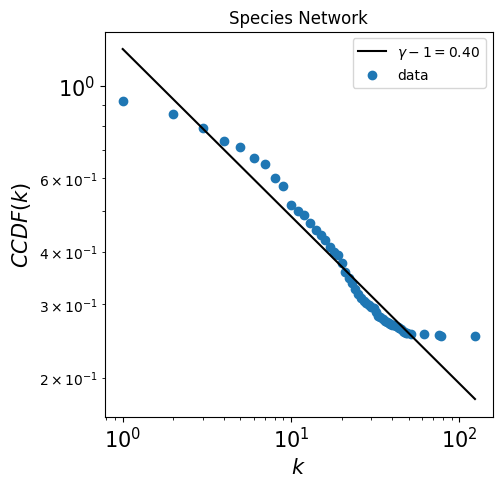

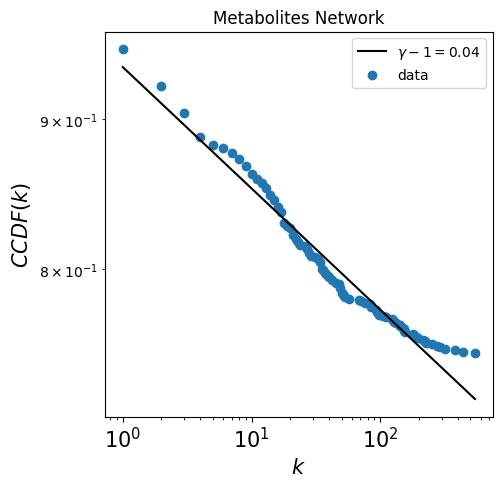

In [31]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

fit_CCDF(B, node_list=species_nodes, title='Species Network')
fit_CCDF(B, node_list=metabolite_nodes, title='Metabolites Network')

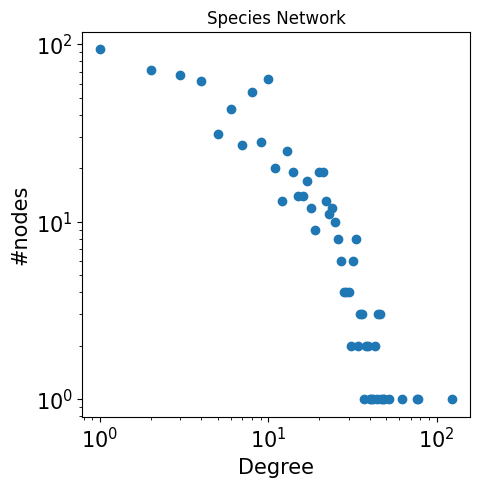

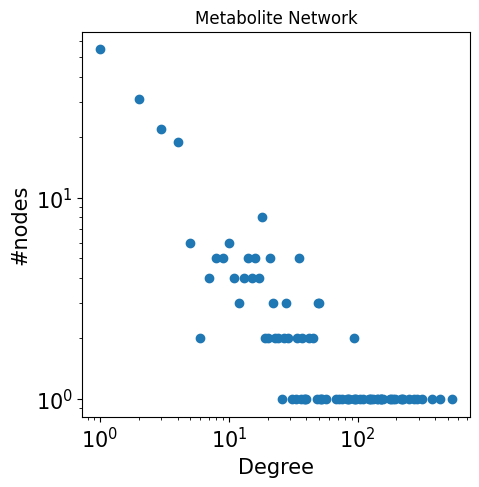

In [39]:
represent_degree_distribution(
    B,
    node_list=species_nodes,
    scale='log',
    rep='scatter',
	title='Species Network'
)

represent_degree_distribution(
    B,
    node_list=metabolite_nodes,
    scale='log',
    rep='scatter',
	title='Metabolite Network'
	
)

## Robustness of the bipartite network 

In [51]:
def largest_component_size(G):

    # convert to undirected for connectivity analysis
    H = G.to_undirected()

    components = list(nx.connected_components(H))

    if len(components) == 0:
        return 0

    return max(len(c) for c in components)


def attack_simulation(G, nodes, strategy="random", centrality=None, steps=50):

    G = G.copy()

    results = []

    # ---------------------------------------------
    # ranking strategy
    # ---------------------------------------------

    if strategy == "random":
        ranked = nodes.copy()

    elif strategy == "degree":
        ranked = sorted(nodes, key=lambda n: G.degree(n), reverse=True)

    elif strategy == "centrality":
        ranked = sorted(nodes, key=lambda n: centrality.get(n, 0), reverse=True)

    else:
        raise ValueError("Unknown strategy")

    # ---------------------------------------------
    # removal loop
    # ---------------------------------------------

    for i in range(steps):

        if len(ranked) == 0:
            break

        if strategy == "random":
            node = random.choice(ranked)
            ranked.remove(node)
        else:
            node = ranked.pop(0)

        if node in G:
            G.remove_node(node)

        results.append({
            "step": i,
            "LCC": largest_component_size(G)
        })

    return pd.DataFrame(results)

In [43]:
betweenness = nx.betweenness_centrality(B)

In [53]:
all_nodes = list(B.nodes())

In [54]:
random_results = attack_simulation(
    B,
    all_nodes,
    strategy="random",
    steps=50
)

In [59]:
targeted_results = attack_simulation(
    B,
    all_nodes,
    strategy="degree",
    steps=50
)

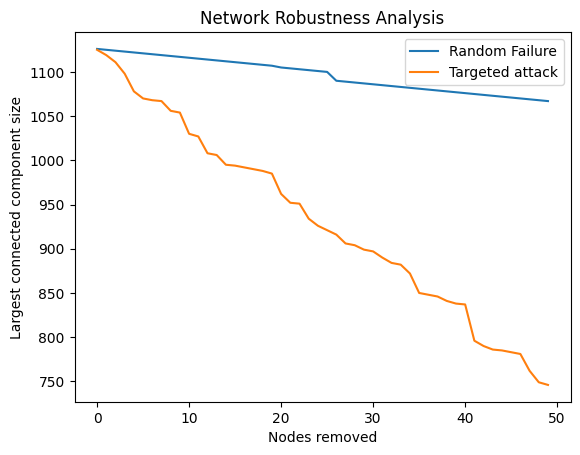

In [60]:
plt.figure()

plt.plot(random_results["step"], random_results["LCC"],
         label="Random Failure")

plt.plot(targeted_results["step"], targeted_results["LCC"],
         label="Targeted attack")

plt.xlabel("Nodes removed")
plt.ylabel("Largest connected component size")
plt.title("Network Robustness Analysis")

plt.legend()
plt.show()

## Robustness of the bipartite network individually

In [44]:
species_attack_random = attack_simulation(
    B,
    species_nodes,
    strategy="random"
)

species_attack_degree = attack_simulation(
    B,
    species_nodes,
    strategy="degree"
)

species_attack_betweenness = attack_simulation(
    B,
    species_nodes,
    strategy="centrality",
    centrality=betweenness
)

In [45]:
metabolite_attack_random = attack_simulation(
    B,
    metabolite_nodes,
    strategy="random"
)

metabolite_attack_degree = attack_simulation(
    B,
    metabolite_nodes,
    strategy="degree"
)

metabolite_attack_betweenness = attack_simulation(
    B,
    metabolite_nodes,
    strategy="centrality",
    centrality=betweenness
)

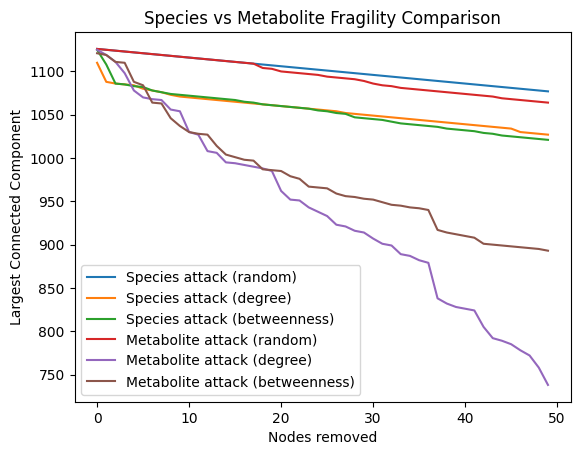

In [50]:
plt.figure()

# Species
plt.plot(species_attack_random["step"], species_attack_random["LCC"],
         label="Species attack (random)")

plt.plot(species_attack_degree["step"], species_attack_degree["LCC"],
         label="Species attack (degree)")

plt.plot(species_attack_betweenness["step"], species_attack_betweenness["LCC"],
         label="Species attack (betweenness)")

# Metabolites
plt.plot(metabolite_attack_random["step"], metabolite_attack_random["LCC"],
         label="Metabolite attack (random)")


plt.plot(metabolite_attack_degree["step"], metabolite_attack_degree["LCC"],
         label="Metabolite attack (degree)")

plt.plot(metabolite_attack_betweenness["step"], metabolite_attack_betweenness["LCC"],
         label="Metabolite attack (betweenness)")

plt.xlabel("Nodes removed")
plt.ylabel("Largest Connected Component")
plt.title("Species vs Metabolite Fragility Comparison")
plt.legend()
plt.show()

## Nestedness

In [66]:
# ---------------------------------------------------------
# UNIQUE NODE LISTS
# ---------------------------------------------------------

species_nodes = sorted(species_nodes)
metabolite_nodes = sorted(metabolite_nodes)

# ---------------------------------------------------------
# INDEX MAPS
# ---------------------------------------------------------

species_index = {
    s: i for i, s in enumerate(species_nodes)
}

metabolite_index = {
    m: j for j, m in enumerate(metabolite_nodes)
}

# ---------------------------------------------------------
# EMPTY MATRIX
# ---------------------------------------------------------

M = np.zeros(
    (len(species_nodes), len(metabolite_nodes)),
    dtype=int
)

# ---------------------------------------------------------
# FILL MATRIX
# ---------------------------------------------------------

for u, v in B.edges():

    u_type = B.nodes[u]["node_type"]
    v_type = B.nodes[v]["node_type"]

    # species -> metabolite
    if u_type == "species":

        s = u
        m = v

    # metabolite -> species
    else:

        s = v
        m = u

    i = species_index[s]
    j = metabolite_index[m]

    M[i, j] = 1

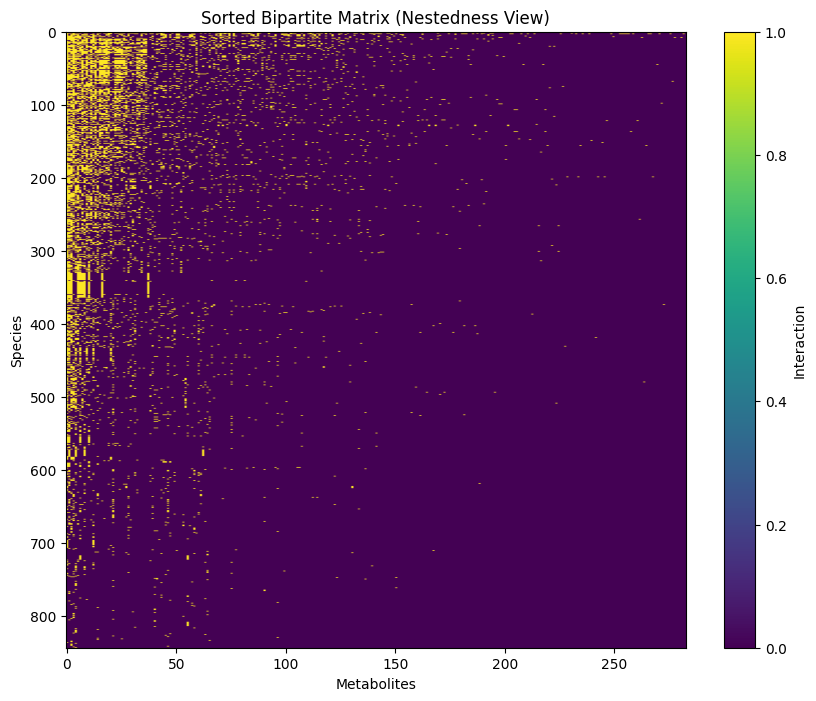

In [69]:
# ---------------------------------------------------------
# sort rows and columns by degree
# ---------------------------------------------------------

row_order = np.argsort(M.sum(axis=1))[::-1]
col_order = np.argsort(M.sum(axis=0))[::-1]

M_sorted = M[row_order][:, col_order]

# ---------------------------------------------------------
# visualize sorted matrix
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(M_sorted, aspect="auto")

plt.title("Sorted Bipartite Matrix (Nestedness View)")
plt.xlabel("Metabolites")
plt.ylabel("Species")

plt.colorbar(label="Interaction")

plt.show()

In [ ]:
# This library doesn't exist but I copy and paste it from the original code 
# in the following repository https://github.com/tsakim/nestedness

class NestednessCalculator(object):
    """Calculates the nestedness of the input matrix.

    The algorithms that have been implemented are:
        - NODF (Nestedness based on Overlap and Decreasing Fill)
    """
    def __init__(self, mat):
        """Initialize the Nestedness calculator and check the input matrix.

        :param mat: binary input matrix
        :type mat: numpy.array
        """
        self.check_input_matrix_is_binary(mat)
        self.check_degrees(mat)

    @staticmethod
    def check_input_matrix_is_binary(mat):
        """Check that the input matrix is binary, i.e. entries are 0 or 1.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix is not
            binary
        """
        assert np.all(np.logical_or(mat == 0, mat == 1)), \
            "Input matrix is not binary."

    @staticmethod
    def check_degrees(mat):
        """Check that rows and columns are not completely zero.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix has
            completely zero rows or columns.
        """
        assert np.all(mat.sum(axis=1) != 0), \
            "Input matrix rows with only zeros, abort."
        assert np.all(mat.sum(axis=0) != 0), \
            "Input matrix columns with only zeros, abort."

################################################################################
# NODF - Nestedness based on Overlap and Decreasing Fill
################################################################################

    def get_paired_nestedness(self, mat, rows=True):
        """Calculate the paired nestedness along the rows or columns of the.

        :param mat: binary input matrix
        :type mat: numpy.array
        :param rows: if True, pairs are calculated along the rows, if False
            along the columns
        :type rows: bool

        :returns: degree of paired nestedness
        :rtype: float

        The method uses the algorithm described in the `BiMat framework for
        MATLAB <https://bimat.github.io/alg/nestedness.html>`_.
        """
        if rows:
            # consider rows
            po_mat = np.dot(mat, mat.T)
            degrees = mat.sum(axis=1)
        else:
            # consider cols
            po_mat = np.dot(mat.T, mat)
            degrees = mat.sum(axis=0)
        assert len(degrees) == len(po_mat)

        neg_delta = (degrees != degrees[:, np.newaxis])
        deg_matrix = degrees * np.ones_like(po_mat)
        deg_minima = np.minimum(deg_matrix, deg_matrix.T)
        n_pairs = po_mat[neg_delta] / (2. * deg_minima[neg_delta])
        return n_pairs.sum()

    def nodf(self, mat):
        """Calculate the NODF nestedness of the input matrix [AlmeidaNeto]_.

        :param mat: binary input matrix
        :type mat: numpy.array

        :returns: NODF nestedness of the input matrix
        :rtype: float


        The algorithm has been tested by comparison with the `online tool
        provided at <http://ecosoft.alwaysdata.net/>`_
        """
        n_pairs_rows = self.get_paired_nestedness(mat, rows=True)
        n_pairs_cols = self.get_paired_nestedness(mat, rows=False)
        norm = np.sum(np.array(mat.shape) * (np.array(mat.shape) - 1) / 2.)
        nodf = (n_pairs_rows + n_pairs_cols) / norm
        return nodf

In [72]:

calculator = NestednessCalculator(M_sorted)

nodf = calculator.nodf(M_sorted)

print("NODF =", nodf)

NODF = 0.2977012779627041


In [77]:
# =========================================================
# NUMBER OF EDGES (L)
# =========================================================

L = B.number_of_edges()

# =========================================================
# NUMBER OF SPECIES (S)
# =========================================================

S = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
])

# =========================================================
# NUMBER OF METABOLITES (M)
# =========================================================

M = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "metabolite" or d.get("bipartite") == 1
])

# =========================================================
# CONNECTANCE
# =========================================================

connectance = L / (S * M)

print("=" * 60)
print("BIPARTITE CONNECTANCE")
print("=" * 60)

print(f"Species (S): {S}")
print(f"Metabolites (M): {M}")
print(f"Links (L): {L}")
print(f"Connectance (C): {connectance:.6f}")

# need to check this better

BIPARTITE CONNECTANCE
Species (S): 844
Metabolites (M): 283
Links (L): 9316
Connectance (C): 0.039003


# Competition Network

In [ ]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "metabolite" or d.get("bipartite") == 1
]

species_to_metabolites = defaultdict(set)

for u, v, d in B.edges(data=True):

    u_type = B.nodes[u].get("node_type")

    if u_type == "species":
        species = u
        metabolite = v
    else:
        species = v
        metabolite = u

        [species].add(metabolite)

In [82]:
competition = nx.Graph()

for s in species_nodes:
    competition.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    m1 = species_to_metabolites[s1]
    m2 = species_to_metabolites[s2]

    if len(m1) == 0 or len(m2) == 0:
        continue

    intersection = len(m1 & m2)
    union = len(m1 | m2)

    if union == 0:
        continue

    weight = intersection / union  # Jaccard similarity

    if weight > 0:

        competition.add_edge(s1, s2, weight=weight)

In [83]:
print("="*60)
print("COMPETITION NETWORK")
print("="*60)

print("Species nodes:", competition.number_of_nodes())
print("Competition edges:", competition.number_of_edges())

COMPETITION NETWORK
Species nodes: 844
Competition edges: 227676


/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_86736/1294712512.py:20: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


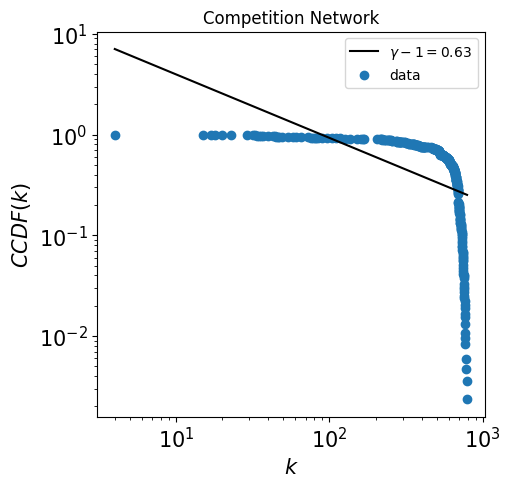

In [150]:
nodes = list(competition.nodes())
fit_CCDF(competition, node_list=nodes, title='Competition Network')

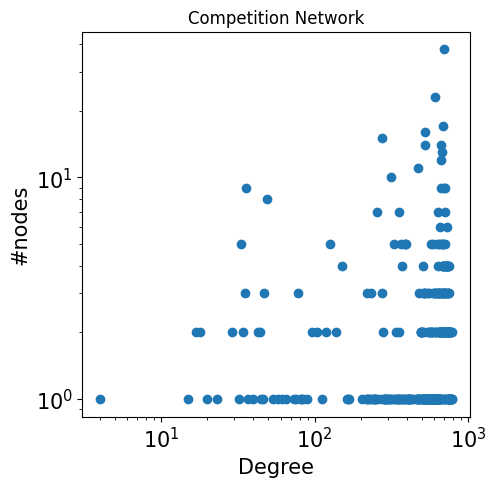

In [151]:
represent_degree_distribution(
    competition,
    node_list=nodes,
    scale='log',
    rep='scatter',
	title='Competition Network'
)

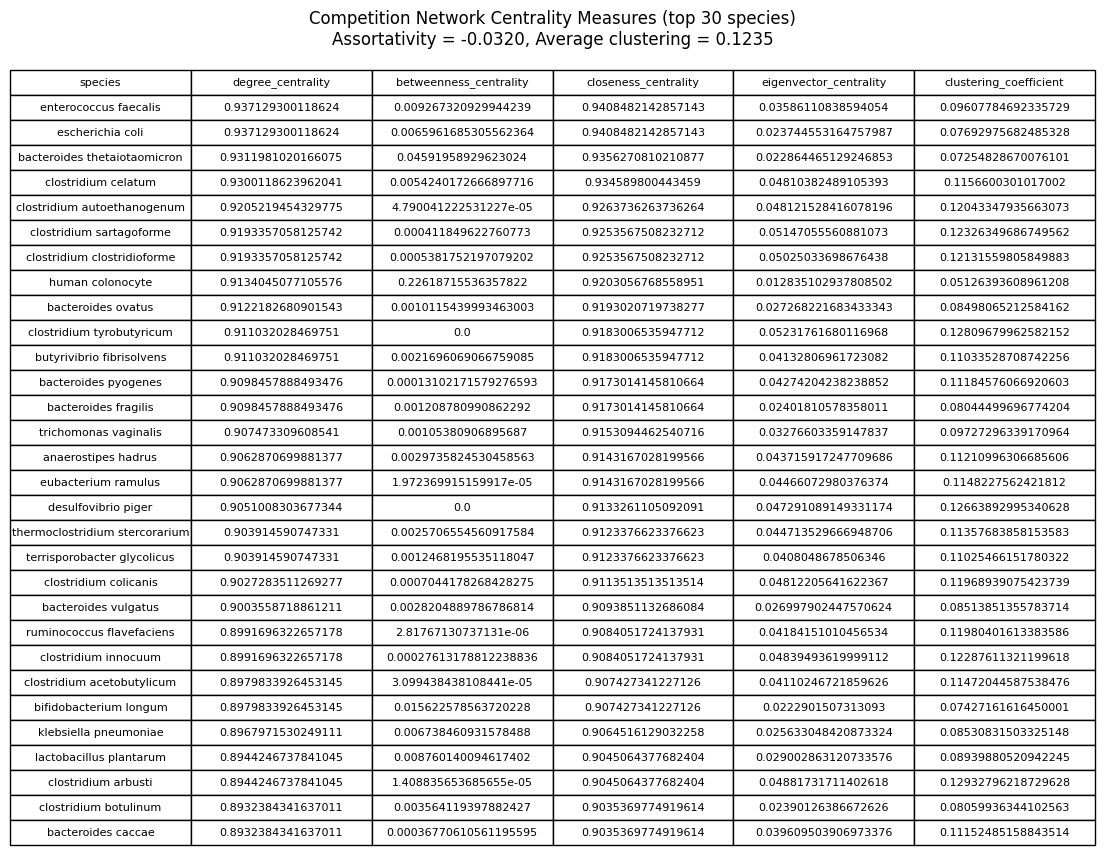

In [147]:
# compute competition network centrality measures
degree_cent = nx.degree_centrality(competition)
bet_cent = nx.betweenness_centrality(competition, weight="weight")
close_cent = nx.closeness_centrality(competition)
eig_cent = nx.eigenvector_centrality(competition, weight="weight", max_iter=1000)
clust = nx.clustering(competition, weight="weight")

assortativity = nx.degree_assortativity_coefficient(competition, weight="weight")
avg_clustering = nx.average_clustering(competition, weight="weight")

competition_df = pd.DataFrame({
	"species": list(competition.nodes()),
	"degree_centrality": [degree_cent[n] for n in competition.nodes()],
	"betweenness_centrality": [bet_cent[n] for n in competition.nodes()],
	"closeness_centrality": [close_cent[n] for n in competition.nodes()],
	"eigenvector_centrality": [eig_cent[n] for n in competition.nodes()],
	"clustering_coefficient": [clust[n] for n in competition.nodes()]
})

competition_df = competition_df.sort_values(
	by="degree_centrality",
	ascending=False
).reset_index(drop=True)

# show the top nodes in a matplotlib table
top_n = 30
top_df = competition_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis("off")

table = ax.table(
	cellText=top_df.values,
	colLabels=top_df.columns,
	cellLoc="center",
	loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

ax.set_title(
	f"Competition Network Centrality Measures (top {top_n} species)\n"
	f"Assortativity = {assortativity:.4f}, "
	f"Average clustering = {avg_clustering:.4f}",
	pad=20
)

plt.show()

# Questions
Which bacteria compete most strongly?
Are there competitive clusters?

Edge weight are
* number of shared metabolites
* Jaccard similarity
* overlap coefficient

In [85]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0   
]

species_to_metabolites = defaultdict(set)

for u, v in B.edges():

    u_type = B.nodes[u].get("node_type")

    if u_type == "species":
        species_to_metabolites[u].add(v)
    else:
        species_to_metabolites[v].add(u)

In [255]:
G_shared = nx.Graph()

for s in species_nodes:
    G_shared.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    w = len(species_to_metabolites[s1] & species_to_metabolites[s2])

    if w > 0:
        G_shared.add_edge(s1, s2, weight=w)

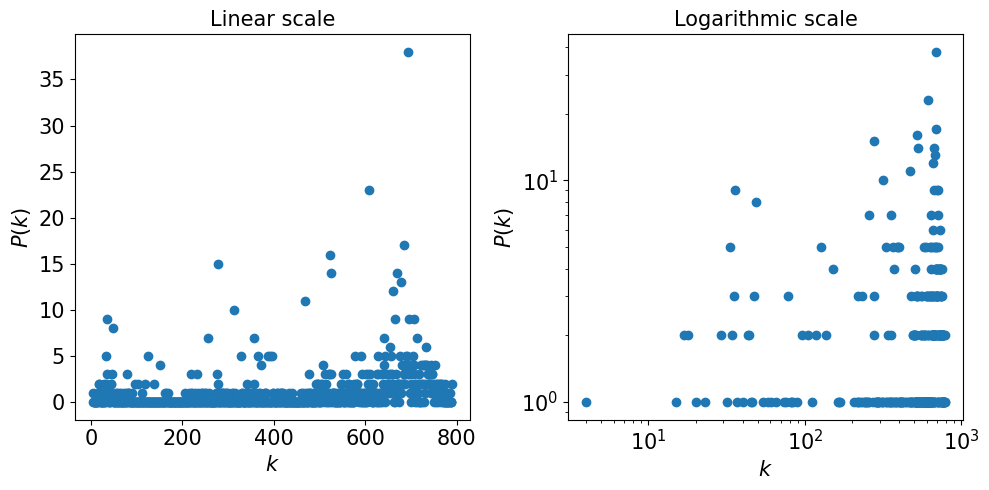

In [256]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_shared.degree(node) for node in G_shared.nodes()]
from collections import Counter

degree_counts = Counter(degree_sequence)
min_degree=min(degree_sequence)
max_degree=max(degree_sequence)

degree = list(range(min_degree, max_degree + 1))
degree_count = [degree_counts.get(x, 0) for x in degree]


ax[0].scatter(degree, degree_count,label='data')
ax[1].scatter(degree, degree_count,label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



In [243]:
G_jaccard = nx.Graph()

for s in species_nodes:
    G_jaccard.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    A = species_to_metabolites[s1]
    Bm = species_to_metabolites[s2]

    if len(A | Bm) == 0:
        continue

    w = len(A & Bm) / len(A | Bm)

    if w > 0:
        G_jaccard.add_edge(s1, s2, weight=w)

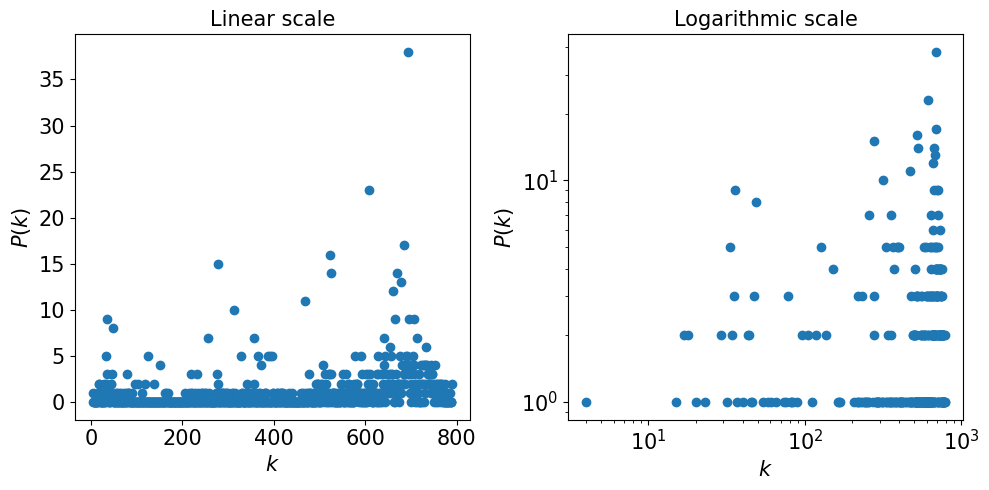

In [253]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_jaccard.degree(node) for node in G_jaccard.nodes()]
from collections import Counter

degree_counts = Counter(degree_sequence)
min_degree=min(degree_sequence)
max_degree=max(degree_sequence)

degree = list(range(min_degree, max_degree + 1))
degree_count = [degree_counts.get(x, 0) for x in degree]


ax[0].scatter(degree, degree_count,label='data')
ax[1].scatter(degree, degree_count,label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



In [ ]:
G_overlap = nx.Graph()

for s in species_nodes:
    G_overlap.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    A = species_to_metabolites[s1]
    Bm = species_to_metabolites[s2]

    denom = min(len(A), len(Bm))

    if denom == 0:
        continue

    w = len(A & Bm) / denom

    if w > 0:
        G_overlap.add_edge(s1, s2, weight=w)

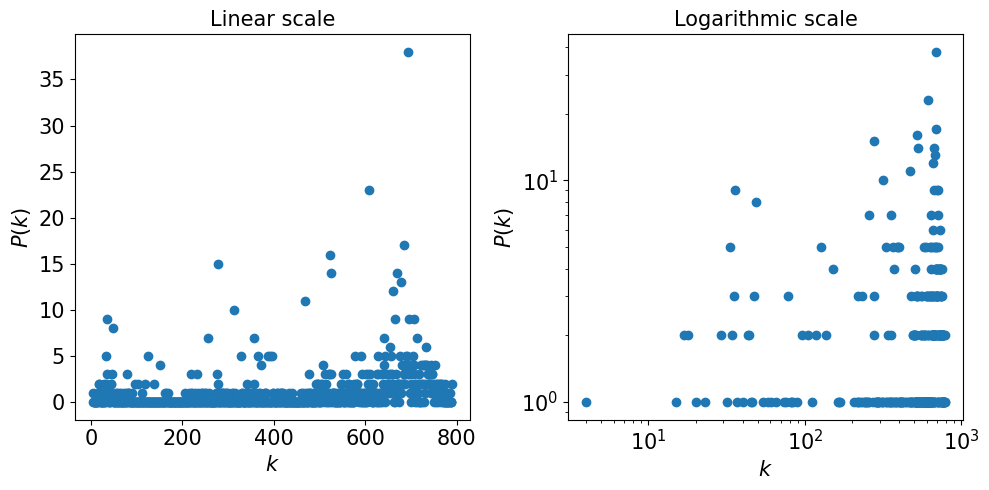

In [254]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_overlap.degree(node) for node in G_overlap.nodes()]
from collections import Counter

degree_counts = Counter(degree_sequence)
min_degree=min(degree_sequence)
max_degree=max(degree_sequence)

degree = list(range(min_degree, max_degree + 1))
degree_count = [degree_counts.get(x, 0) for x in degree]


ax[0].scatter(degree, degree_count,label='data')
ax[1].scatter(degree, degree_count,label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



## Which pairs share the most metabolites?

In [152]:
edges_df = []

for u, v, d in G_shared.edges(data=True):

    edges_df.append({
        "species_1": u,
        "species_2": v,
        "shared_metabolites": d["weight"]
    })

edges_df = pd.DataFrame(edges_df)

edges_df = edges_df.sort_values(
    "shared_metabolites",
    ascending=False
)

print(edges_df.head(20))

                            species_1                               species_2  \
227672               human colonocyte                   mouse intestinal cell   
50933              bacteroides ovatus            bacteroides thetaiotaomicron   
59200    bifidobacterium adolescentis                  bifidobacterium longum   
61665           bifidobacterium breve                  bifidobacterium longum   
61035         bifidobacterium bifidum                  bifidobacterium longum   
59195    bifidobacterium adolescentis                 bifidobacterium bifidum   
61031         bifidobacterium bifidum                   bifidobacterium breve   
98118             clostridium celatum             clostridium clostridioforme   
57029    bacteroides thetaiotaomicron                        human colonocyte   
59196    bifidobacterium adolescentis                   bifidobacterium breve   
56352    bacteroides thetaiotaomicron                    bacteroides vulgatus   
60419        bifidobacterium

## modularity

In [157]:
louvain_partition = community_louvain.best_partition(
    G_jaccard,
    weight="weight",
    random_state=42
)

# ---------------------------------------------------------
# Compute modularity score
# ---------------------------------------------------------

louvain_modularity = community_louvain.modularity(
    louvain_partition,
    G_jaccard,
    weight="weight"
)

print("=" * 60)
print("LOUVAIN MODULARITY")
print("=" * 60)
print(f"Modularity Q: {louvain_modularity:.4f}")

LOUVAIN MODULARITY
Modularity Q: 0.1932


In [158]:
louvain_modules = defaultdict(list)

for node, module_id in louvain_partition.items():
    louvain_modules[module_id].append(node)

print("\nMODULE SIZES\n")

for module_id, species in louvain_modules.items():

    print(
        f"Module {module_id}: "
        f"{len(species)} species"
    )



MODULE SIZES

Module 0: 245 species
Module 1: 260 species
Module 2: 91 species
Module 3: 87 species
Module 5: 150 species
Module 4: 11 species


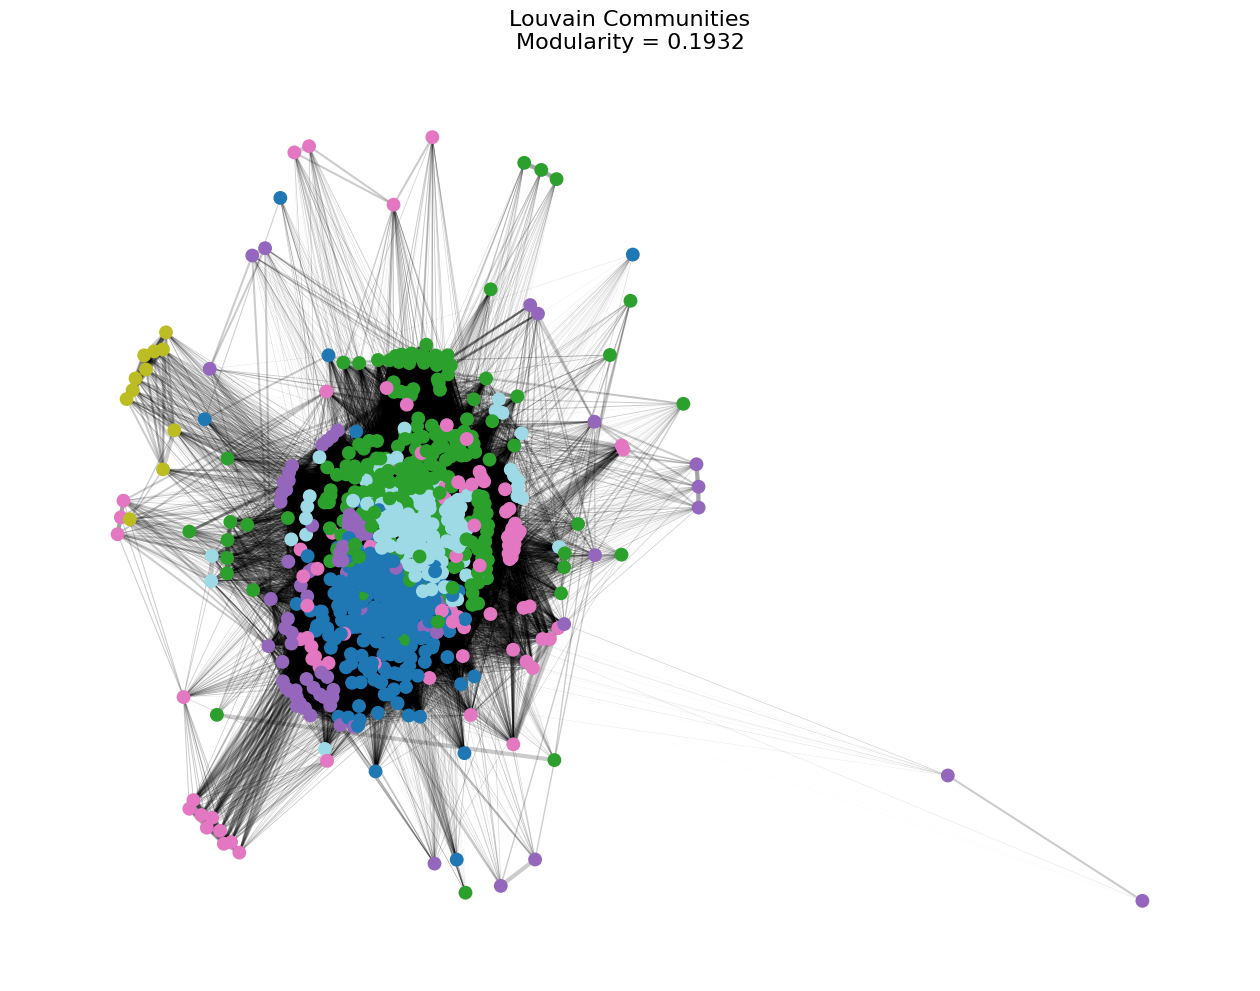

In [159]:
pos = nx.spring_layout(
    G_jaccard,
    seed=42,
    k=0.15
)

# ---------------------------------------------------------
# Node colors
# ---------------------------------------------------------

node_colors = [
    louvain_partition[node]
    for node in G_jaccard.nodes()
]

# ---------------------------------------------------------
# Edge widths from weights
# ---------------------------------------------------------

edge_widths = [
    d["weight"] * 3
    for _, _, d in G_jaccard.edges(data=True)
]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(16, 12))

nx.draw_networkx_nodes(
    G_jaccard,
    pos,
    node_size=80,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G_jaccard,
    pos,
    alpha=0.2,
    width=edge_widths
)

plt.title(
    f"Louvain Communities\n"
    f"Modularity = {louvain_modularity:.4f}",
    fontsize=16
)

plt.axis("off")

plt.show()

In [160]:
from networkx.algorithms.community import (
    greedy_modularity_communities
)
from networkx.algorithms.community.quality import modularity


greedy_communities = greedy_modularity_communities(
    G_jaccard,
    weight="weight"
)

greedy_partition = {}

for i, comm in enumerate(greedy_communities):

    for node in comm:

        greedy_partition[node] = i
        

greedy_modularity = modularity(
    G_jaccard,
    greedy_communities,
    weight="weight"
)

print("\n")
print("=" * 60)
print("GREEDY MODULARITY")
print("=" * 60)

print(f"Modularity Q: {greedy_modularity:.4f}")



GREEDY MODULARITY
Modularity Q: 0.1642


In [161]:
print("\nMODULE SIZES\n")

for i, comm in enumerate(greedy_communities):

    print(
        f"Module {i}: "
        f"{len(comm)} species"
    )


MODULE SIZES

Module 0: 355 species
Module 1: 275 species
Module 2: 197 species
Module 3: 12 species
Module 4: 3 species
Module 5: 2 species


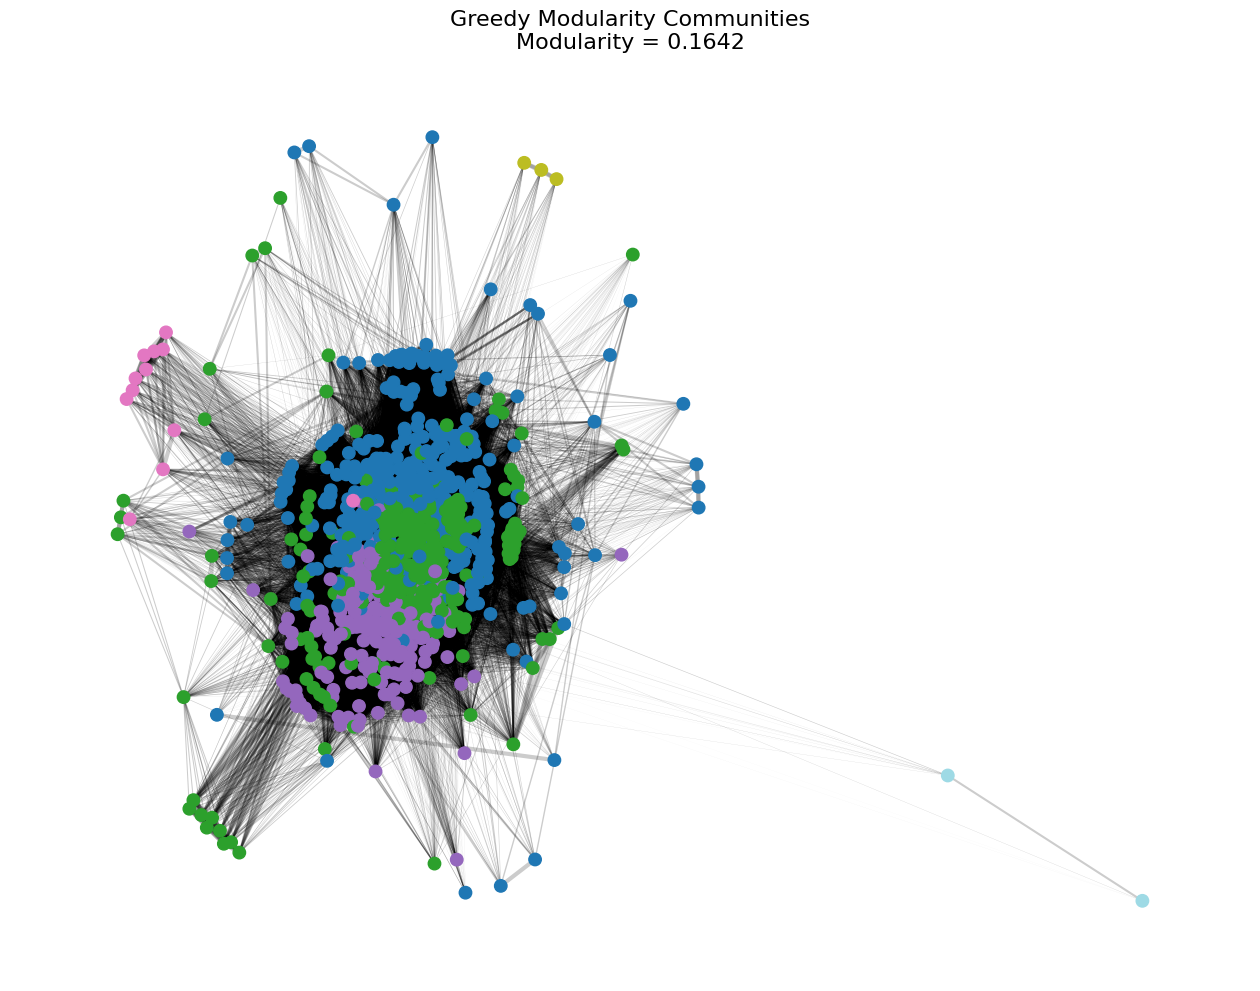

In [162]:
node_colors = [
    greedy_partition[node]
    for node in G_jaccard.nodes()
]

plt.figure(figsize=(16, 12))

nx.draw_networkx_nodes(
    G_jaccard,
    pos,
    node_size=80,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G_jaccard,
    pos,
    alpha=0.2,
    width=edge_widths
)

plt.title(
    f"Greedy Modularity Communities\n"
    f"Modularity = {greedy_modularity:.4f}",
    fontsize=16
)

plt.axis("off")

plt.show()


In [163]:
comparison_df = pd.DataFrame({
    "method": ["Louvain", "Greedy"],
    "modularity": [
        louvain_modularity,
        greedy_modularity
    ],
    "num_modules": [
        len(set(louvain_partition.values())),
        len(greedy_communities)
    ]
})

print("\n")
print("=" * 60)
print("COMPARISON")
print("=" * 60)

print(comparison_df)



COMPARISON
    method  modularity  num_modules
0  Louvain    0.193176            6
1   Greedy    0.164232            6


In [164]:
print("\n")
print("=" * 60)
print("SPECIES PER LOUVAIN MODULE")
print("=" * 60)

for module_id, species in louvain_modules.items():

    print(f"\nMODULE {module_id}")

    for s in sorted(species)[:15]:

        print(" -", s)



SPECIES PER LOUVAIN MODULE

MODULE 0
 - absiella dolichum
 - acetobacterium woodii
 - achromobacter xylosoxidans
 - acidovorax avenae
 - acidovorax delafieldii
 - actinobacillus succinogenes
 - actinosynnema mirum
 - aerococcus viridans
 - aeromicrobium marinum
 - aeromonas hydrophila
 - aeromonas salmonicida
 - alistipes indistinctus
 - alloprevotella rava
 - anaerobutyricum hallii
 - anaerococcus hydrogenalis

MODULE 1
 - acetoanaerobium sticklandii
 - acetobacter pasteurianus
 - acetohalobium arabaticum
 - acidithiobacillus caldus
 - actinomyces coleocanis
 - actinomyces oris
 - actinomyces urogenitalis
 - actinomyces viscosus
 - akkermansia muciniphila
 - alistipes finegoldii
 - alistipes obesi
 - alistipes onderdonkii
 - alistipes putredinis
 - alistipes senegalensis
 - alistipes shahii

MODULE 2
 - acholeplasma laidlawii
 - acidiphilium cryptum
 - aeropyrum pernix
 - aggregatibacter actinomycetemcomitans
 - alicycliphilus denitrificans
 - archaeoglobus fulgidus
 - azotobacter v

## Are the competition modules dynamically stable?

In [224]:
# =========================================================
# SELECT MODULE
# =========================================================

target_module = 0

module_species = louvain_modules[target_module]

print("=" * 60)
print("TARGET MODULE")
print("=" * 60)

print(f"Module: {target_module}")
print(f"Species count: {len(module_species)}")

TARGET MODULE
Module: 0
Species count: 245


In [225]:
# =========================================================
# SPECIES INDEX
# =========================================================

species_index = {
    s: i
    for i, s in enumerate(module_species)
}

index_species = {
    i: s
    for s, i in species_index.items()
}

n = len(module_species)

print(f"Matrix size: {n} x {n}")

Matrix size: 245 x 245


In [226]:
A = np.zeros((n, n))

In [227]:
for s1, s2, d in G_jaccard.edges(data=True):

    if s1 not in species_index:
        continue

    if s2 not in species_index:
        continue

    i = species_index[s1]
    j = species_index[s2]

    weight = d["weight"]

    A[i, j] = weight
    A[j, i] = weight

In [228]:
for i in range(n):

    A[i, i] = 1.0

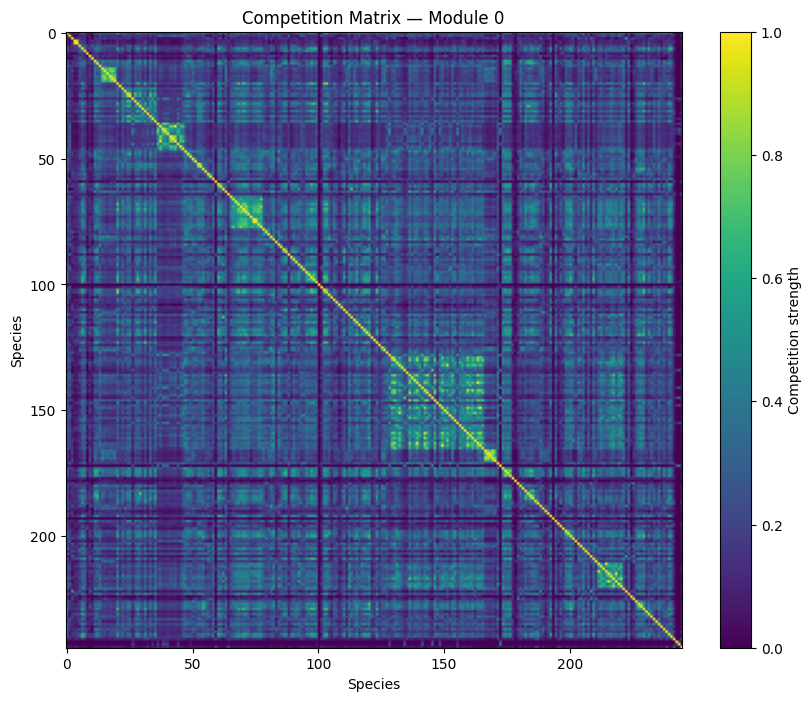

In [229]:
plt.figure(figsize=(10, 8))

plt.imshow(
    A,
    cmap="viridis"
)

plt.colorbar(label="Competition strength")

plt.title(
    f"Competition Matrix — Module {target_module}"
)

plt.xlabel("Species")
plt.ylabel("Species")

plt.show()

In [230]:
# =========================================================
# GROWTH RATES
# =========================================================

r = np.random.uniform(
    0.5,
    1.5,
    size=n
)

print("Growth rates:\n")
print(r)

Growth rates:

[1.4003539  1.32690007 1.12855059 0.56912804 0.63646915 1.16872164
 0.62023137 0.91688894 1.18548156 0.72259523 0.74053737 0.85304655
 0.68919484 1.05777283 1.01197547 1.21632646 1.10347783 1.21394194
 1.37993711 1.27625786 1.06517355 1.19058549 1.2086141  1.14353434
 1.20063195 1.17210913 1.23247965 0.87095449 0.986083   0.7084733
 1.32648572 0.74765297 0.5722159  0.97197356 0.75476008 0.79033336
 0.98887954 1.06072594 0.9383244  1.083204   0.66901703 1.32629304
 1.13679445 0.95372027 1.32019072 1.03005704 1.12111379 0.76654329
 0.56155367 1.49012576 0.94190906 1.21849363 0.89956077 0.71531401
 1.49898095 1.07745478 1.06469177 0.83432331 1.27298858 1.48086953
 1.33273972 1.21878648 1.4922432  1.38811919 0.96847531 0.69563347
 1.20318985 1.04170636 0.68659077 1.3110341  0.98445721 1.48672684
 0.51505227 0.65512642 0.95520392 0.80063817 0.67295562 0.9969476
 1.41931338 1.44322184 0.66477138 0.53997205 0.99267929 1.31292702
 1.22382358 0.72219623 1.10246133 1.07481039 1.02

In [231]:
# =========================================================
# INITIAL CONDITIONS
# =========================================================

N0 = np.random.uniform(
    0.1,
    1.0,
    size=n
)

print("Initial abundances:\n")
print(N0)

Initial abundances:

[0.30609152 0.44744422 0.44855113 0.95560872 0.25669287 0.92613702
 0.7128699  0.86347716 0.25191448 0.21385862 0.81478544 0.25132926
 0.42427722 0.99239855 0.44887007 0.33997338 0.12577304 0.76016086
 0.48182738 0.33670575 0.26815879 0.66848222 0.640527   0.91206599
 0.33740485 0.18507746 0.21961401 0.31211652 0.18386571 0.45652815
 0.42832741 0.39173361 0.6839214  0.55451179 0.85582921 0.7916712
 0.76749579 0.28915133 0.42392091 0.16664329 0.25889429 0.45680363
 0.79929553 0.3447583  0.85245253 0.18542598 0.81079776 0.69903729
 0.60131677 0.84794066 0.66299142 0.69977945 0.41138196 0.98916134
 0.85128457 0.92788022 0.98521432 0.22213901 0.74243947 0.10329014
 0.33313838 0.2486247  0.22154323 0.43791416 0.20287809 0.18109145
 0.71738897 0.80748973 0.12077836 0.51377076 0.86382354 0.49311729
 0.77553698 0.61978459 0.4902518  0.63000664 0.95887622 0.32192817
 0.32534899 0.6077027  0.75429029 0.23884053 0.1907349  0.73831981
 0.92669944 0.94132216 0.87505928 0.466214

In [232]:
from scipy.integrate import solve_ivp

In [233]:
# =========================================================
# GENERALIZED LOTKA–VOLTERRA
# =========================================================

def glv(t, N, r, A):

    dNdt = np.zeros_like(N)

    for i in range(len(N)):

        interaction_term = np.sum(
            A[i] * N
        )

        dNdt[i] = (
            r[i]
            * N[i]
            * (1 - interaction_term)
        )

    return dNdt

In [234]:
# =========================================================
# TIME SPAN
# =========================================================

t_span = (0, 100)

t_eval = np.linspace(
    0,
    100,
    1000
)

In [235]:
# =========================================================
# SOLVE ODE SYSTEM
# =========================================================

solution = solve_ivp(
    glv,
    t_span,
    N0,
    args=(r, A),
    t_eval=t_eval
)

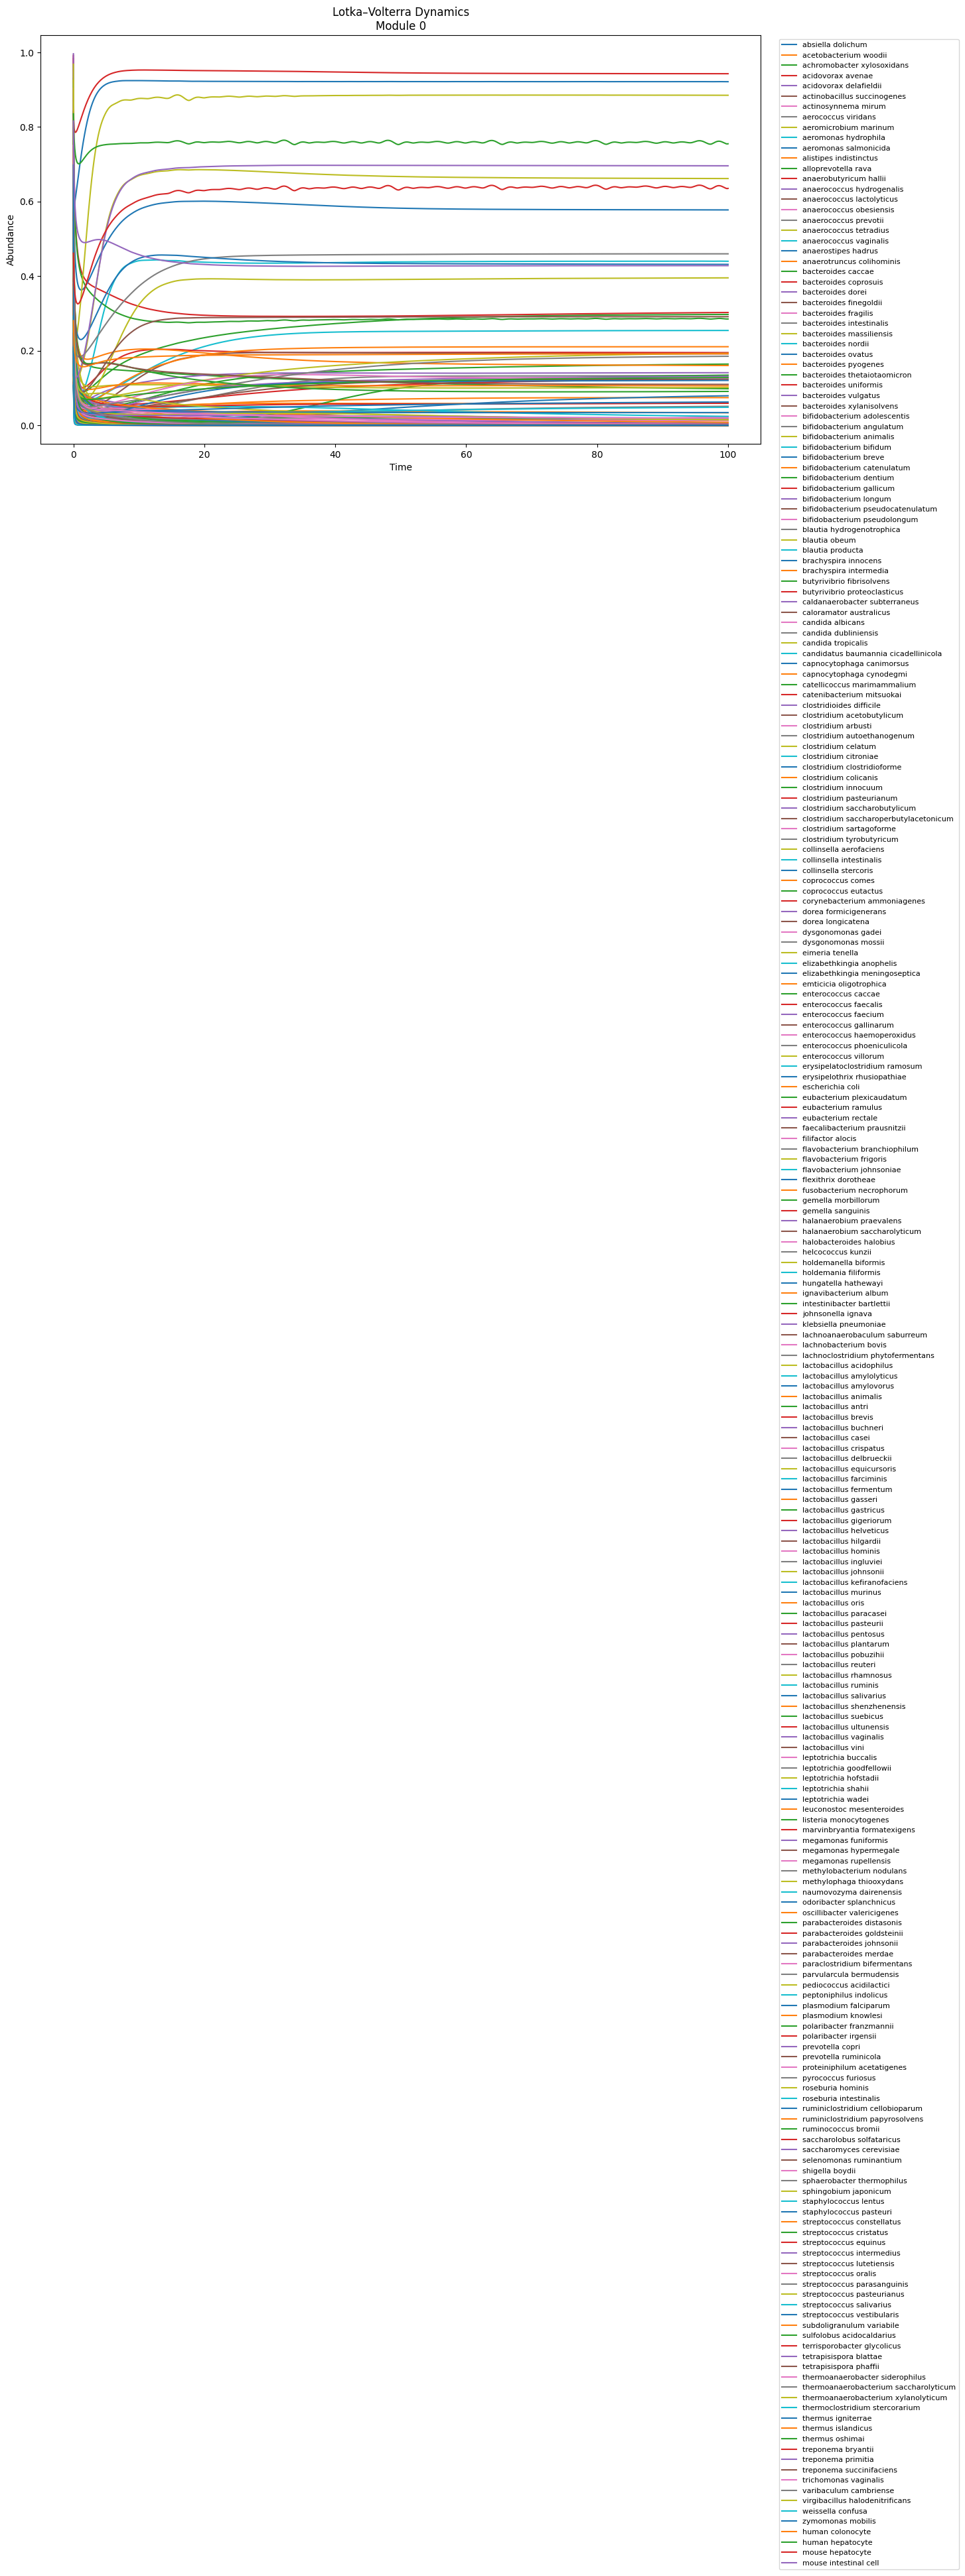

In [262]:
plt.figure(figsize=(14, 8))

for i in range(n):

    plt.plot(
        solution.t,
        solution.y[i],
        label=index_species[i]
    )

plt.xlabel("Time")
plt.ylabel("Abundance")

plt.title(
    f"Lotka–Volterra Dynamics\n"
    f"Module {target_module}"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.show()

In [237]:
final_abundance = solution.y[:, -1]

results_df = pd.DataFrame({
    "species": [
        index_species[i]
        for i in range(n)
    ],
    "final_abundance": final_abundance
})

results_df = results_df.sort_values(
    "final_abundance",
    ascending=False
)

results_df

,species,final_abundance
193,polaribacter irgensii,9.428393e-01
100,erysipelothrix rhusiopathiae,9.214159e-01
178,methylophaga thiooxydans,8.850186e-01
242,human hepatocyte,7.549109e-01
224,tetrapisispora blattae,6.958458e-01
...,...,...
71,clostridium colicanis,2.866821e-24
146,lactobacillus hominis,1.925617e-24
239,weissella confusa,1.260775e-25
188,pediococcus acidilactici,7.244770e-26


In [238]:
EXTINCTION_THRESHOLD = 1e-3

extinct = results_df[
    results_df["final_abundance"]
    < EXTINCTION_THRESHOLD
]

print("=" * 60)
print("EXTINCT SPECIES")
print("=" * 60)

print(extinct)

EXTINCT SPECIES
                       species  final_abundance
14   anaerococcus hydrogenalis     9.963343e-04
116   halobacteroides halobius     8.769394e-04
19      anaerococcus vaginalis     6.783119e-04
18      anaerococcus tetradius     5.748346e-04
37   bifidobacterium angulatum     5.230432e-04
..                         ...              ...
71       clostridium colicanis     2.866821e-24
146      lactobacillus hominis     1.925617e-24
239          weissella confusa     1.260775e-25
188   pediococcus acidilactici     7.244770e-26
63   catenibacterium mitsuokai     1.376579e-26

[170 rows x 2 columns]


In [239]:
module_metabolites = {}

for s in list(results_df['species']):
    module_metabolites[s] = species_to_metabolites[s]

In [240]:
from functools import reduce

shared_core = reduce(
    lambda a, b: a & b,
    module_metabolites.values()
)

print("CORE METABOLITES (shared by all species):")
print(shared_core)

CORE METABOLITES (shared by all species):
set()
